##### Análisis y Procesamiento de Señales
# Trabajo Semanal n°1: Síntesis y operaciones de señales.
#### hecho por Tomás Ladiani [git](https://github.com/TLadiani)

## Ejercicio 1
Utilizando siempre N = 1000 muestras. Se pide:

Sintetizar:
1. Señal sinusoidal de 2 KHz que tenga al menos 10 puntos por período.
2. Misma señal con 2 W de potencia media y desfasada en π/2.
3. Una secuencia aleatoria de ruido normalmente distribuido con DC (valor medio) 0V y varianza 0.1 W.
4. Una secuencia aleatoria de ruido uniformemente distribuido con DC (valor medio) 0V y varianza 0.1 W.
5. Un pulso rectangular de la misma frecuencia, 1 W de potencia y ciclo de actividad del 50% (Ver scipy.signal apartado Waveforms).
  
Para cada señal visualice el módulo de la transformada de Fourier.

Librerías:

In [1]:
#librerías
import numpy as np
import matplotlib.pyplot as plt
from scipy import signal
from scipy.signal import square, unit_impulse
from scipy.fft import fft, fftshift, fftfreq

Funciones para generar las señales y graficar:

In [2]:
#% Funciones
def gen_sin(vmax=1.0, dc=0.0, ff=1.0, ph=0.0, nn=1000, fs=1000.0):
    
    ts = 1.0 / fs
    tt = np.arange(0, nn * ts, ts)
    tt = tt[:nn] 
    xx = vmax * np.sin(2 * np.pi * ff * tt + ph) + dc
    
    return tt, xx

def gen_square(vmax=1.0, dc=0.0, ff=1.0, ph=0.0, duty=0.5, nn=1000, fs=1000.0):

    ts = 1.0 / fs
    tt = np.arange(0, nn * ts, ts)
    tt = tt[:nn]
    
    # La función square genera una onda cuadrada entre -1 y 1
    xx = vmax * square(2 * np.pi * ff * tt + ph, duty) + dc
    
    return tt, xx

def gen_impulso(nn=1000, posicion=0, fs=1000.0):
    
    ts = 1.0 / fs
    tt = np.arange(0, nn * ts, ts)
    tt = tt[:nn]
    
    # Genera un vector de ceros con un valor 1 en el índice 'posicion'
    xx = unit_impulse(nn, idx=posicion)
    
    return tt, xx

def gen_ruido(varianza=0.1, distribucion='normal', nn=1000, fs=1000.0):
    
    ts = 1.0 / fs
    tt = np.arange(0, nn * ts, ts)
    tt = tt[:nn]
    
    if distribucion == 'normal':
        # La desviación estándar es la raíz cuadrada de la varianza
        desvio_estandar = np.sqrt(varianza)
        xx = np.random.normal(loc=0.0, scale=desvio_estandar, size=nn)
        
    elif distribucion == 'uniforme':
        # Para una distribución uniforme entre [-a, a], la varianza es (a^2)/3
        # Despejando 'a' para obtener la varianza deseada: a = sqrt(3 * varianza)
        a = np.sqrt(3 * varianza) 
        xx = np.random.uniform(low=-a, high=a, size=nn)
        
    else:
        raise ValueError("La distribución debe ser 'normal' o 'uniforme'.")
        
    return tt, xx

def graficar_dual(tt, xx, fs, ff, titulo_principal="Análisis de Señal"):
    
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
    
    # Gráfico en el tiempo (restringido a un período T0 = 1/ff si ff > 0, sino muestra todo)
    if ff > 0:
        periodo = 1.0 / ff
        # Filtra el vector de tiempo para mostrar solo un ciclo (o al menos un par de ellos para visualización clara)
        mask = tt <= (2 * periodo) if tt[-1] >= (2 * periodo) else (tt <= tt[-1])
        ax1.plot(tt[mask], xx[mask])
        ax1.set_title("Dominio Temporal (Detalle)")
    else:
        ax1.plot(tt, xx)
        ax1.set_title("Dominio Temporal")
        
    ax1.set_xlabel("Tiempo [s]")
    ax1.set_ylabel("Amplitud [V]")
    ax1.grid(True, linestyle='--', alpha=0.7)
    
    # Gráfico en frecuencia (Espectro)
    nn = len(xx)
    X = fft(xx)
    X_mod = np.abs(X) / nn
    ff_vec = fftfreq(nn, 1/fs)
    
    X_mod_sh = fftshift(X_mod)
    ff_vec_sh = fftshift(ff_vec)
    
    ax2.stem(ff_vec_sh, X_mod_sh)
    ax2.set_title("Espectro de Frecuencia")
    ax2.set_xlabel("Frecuencia [Hz]")
    ax2.set_ylabel("Módulo Normalizado")
    ax2.grid(True, linestyle='--', alpha=0.7)
    
    fig.suptitle(titulo_principal, fontsize=14)
    plt.tight_layout()
    plt.show()

### 1. Señal sinusoidal de 2 KHz y 10 muestras por periodo
para lograr los 10 puntos por periodo es necesario calcular la frecuencia de sampleo en base a la frecuencia de operación de 2KHz

$fs = 1/T_0   \to   T_0 = 1/f = 1/2000Hz   \to   T_s = T_0 / 10(muestras)   \to   fs >= 20KHz$

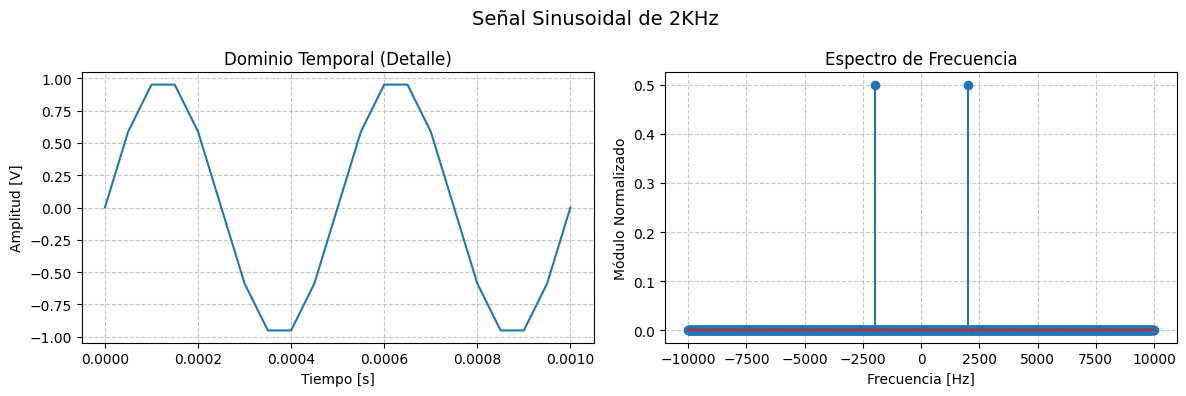

In [3]:
#%% Señal 1: Sinusoidal de 2 kHz

# Parámetros y síntesis
N = 1000
fs = 20000
tt, xx = gen_sin(vmax=1.0, ff=2000, nn=N, fs=fs)
graficar_dual(tt, xx, fs, 2000, titulo_principal="Señal Sinusoidal de 2KHz")

### 2. Misma señal sinusoidal con potencia de 2W y desfase de 90°
la potencia de una señal de define como $P = (Vmax)^2/2$ para que esta sea de 2W es necesario tener Vmax = 2V

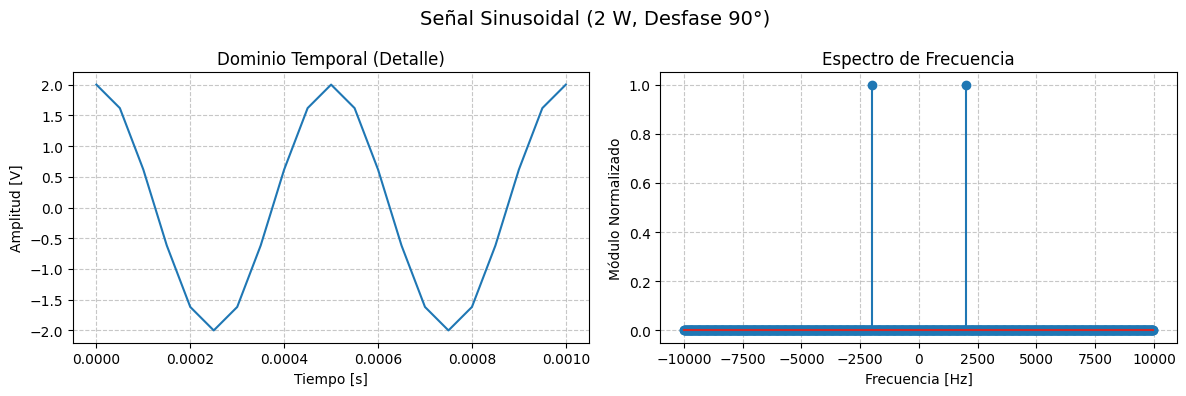

In [4]:
#%% Señal 2: Sinusoidal 2W y desfasada
ff_2 = 2000
fs_2 = 20000
vmax_2 = 2
ph_2 = np.pi / 2

tt2, xx2 = gen_sin(vmax=2, ff=2000, ph= (np.pi)/2, nn=N, fs=20000)

graficar_dual(tt2, xx2, fs=20000, ff=2000, titulo_principal="Señal Sinusoidal (2 W, Desfase 90°)")

### 3. Ruido con Distribución Normal (Gaussiano)
- **Comportamiento de la amplitud**: Los valores de la señal tienden a concentrarse fuertemente alrededor de la media (en este caso, 0 V). A medida que un valor se aleja de la media, su probabilidad de ocurrencia disminuye de forma exponencial, siguiendo la clásica curva de campana de Gauss.
- **Extremos**: Teóricamente, no hay límites estrictos (mínimo o máximo absoluto); existe una probabilidad (aunque extremadamente baja) de encontrar valores de amplitud muy elevados.
- **Modelo físico**: Es el modelo por excelencia para representar el ruido térmico en componentes electrónicos (ruido Johnson-Nyquist) y una gran variedad de ruidos naturales originados por la superposición de múltiples fuentes aleatorias independientes (Teorema del Límite Central).

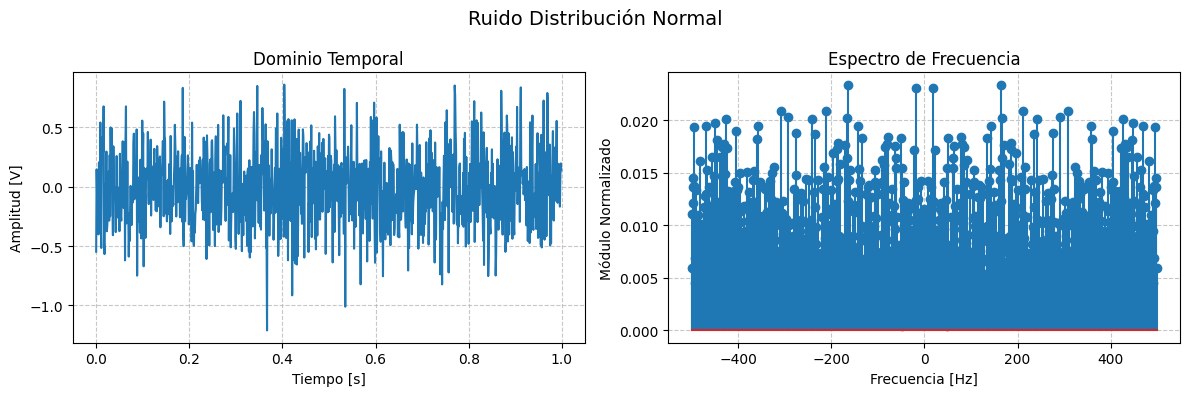

In [5]:
#%% Señal 3: Ruido Distribución Normal
fs=1000
tt3,xx3 = gen_ruido(varianza=0.1, distribucion='normal')

graficar_dual(tt3, xx3, fs, ff=0, titulo_principal="Ruido Distribución Normal") #mi función usa ff=0 para explicitar que la señal no tiene periodo

### 4. Ruido con Distribución Uniforme 
- **Comportamiento de la amplitud**: Todos los valores de amplitud dentro de un intervalo específico y acotado (definido entre -a y a) tienen exactamente la misma probabilidad de ocurrencia. No hay preferencia por el valor central ni por ningún otro.
- **Extremos**: Está estrictamente acotado. La señal nunca superará los límites establecidos (+a o -a); la probabilidad de encontrarse fuera de ese rango es exactamente cero.
- **Modelo físico**: Es el modelo estándar para representar errores de cuantización en sistemas digitales (como el paso de una señal analógica a un conversor ADC) o ruido de redondeo en operaciones de procesamiento numérico.

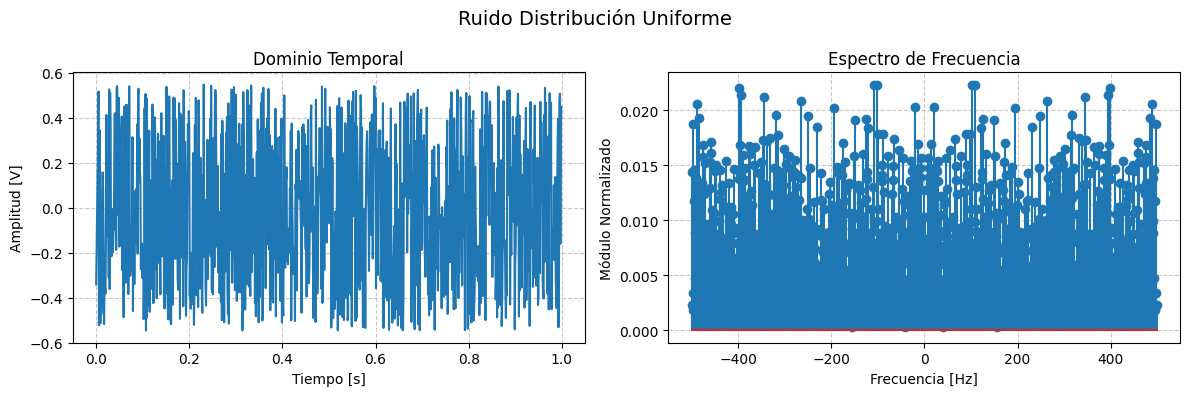

In [6]:
#%% Señal 4: Ruido Distribución Uniforme
fs=1000
tt4,xx4 = gen_ruido(varianza=0.1, distribucion='uniforme')

graficar_dual(tt4, xx4, fs, ff=0, titulo_principal="Ruido Distribución Uniforme") #mi función usa ff=0 para explicitar que la señal no tiene periodo

### Diferencias
1. Dominio Temporal (Amplitud y Acotamiento)
Ruido Normal: La representación en el tiempo muestra fluctuaciones irregulares donde la gran mayoría de las amplitudes se concentran cerca del cero, pero con apariciones puntuales de picos de mayor magnitud (valores altos o bajos) debido a la forma de la campana de Gauss.

Ruido Uniforme: El gráfico temporal exhibe una "franja" o banda horizontal de amplitud estrictamente delimitada. Las amplitudes llenan ese espacio de forma homogénea sin sobrepasar los límites superior e inferior.

2. Dominio Frecuencial (Espectro)
Ambos gráficos de espectro mostrarán una distribución de energía aproximadamente plana y distribuida a lo largo de todo el ancho de banda (característica del ruido blanco generado mediante muestras independientes). Sin embargo, la dispersión puntual de las líneas espectrales diferirá debido a la naturaleza estocástica de cada realización aleatoria.

### 5. Pulso Cuadrado
Para que la señal sea de 1W es necesario que la Vmax sea de $\sqrt(2)$

#### Análisis Espectral del Pulso Rectangular
En el gráfico del espectro de frecuencias se observará que, a diferencia de la señal senoidal pura (que concentra su energía en una única línea espectral en $2\text{ kHz}$), el pulso rectangular presenta un espectro armónico. Este se compone de la frecuencia fundamental y sus armónicos impares ($3f_0, 5f_0, 7f_0, \dots$), cuyas amplitudes decrecen siguiendo una envolvente de tipo sinc.

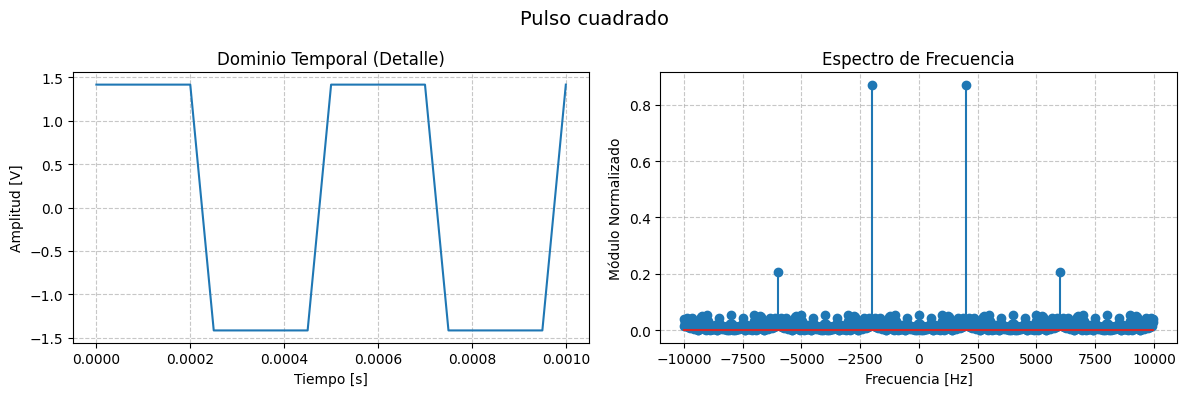

In [7]:
#%% Señal 5: Pulso cuadrado
tt5,xx5 = gen_square(vmax=(np.sqrt(2)), ff=2000, fs=20000)

graficar_dual(tt5, xx5, 20000, 2000, titulo_principal="Pulso cuadrado") #mi función usa ff=0 para explicitar que la señal no tiene periodo

### Bonus
Consigna: Implementar alguna otra señal disponible en scipy.signal.
Averiguar cómo se podría medir la potencia mediante la transformada de Fourier (Ver Teorema de Parseval)

#### Impulso Unitario:
Desde la perspectiva espectral, al estar concentrada en un único instante temporal, su energía se distribuye equitativamente en todo el ancho de banda accesible (hasta la frecuencia de Nyquist). Por esta razón, el módulo de su Transformada de Fourier resulta plano y constante, constituyendo una señal de referencia para caracterizar la respuesta en frecuencia de los sistemas.


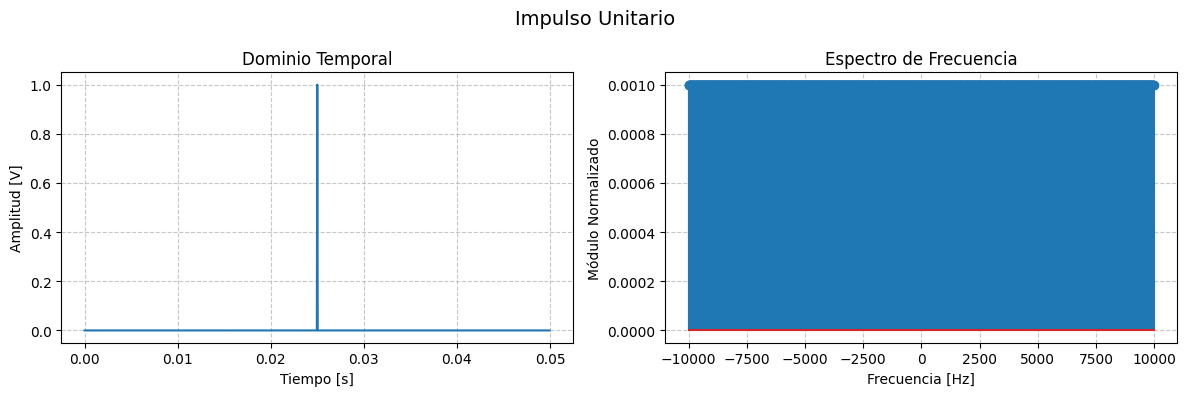

In [8]:
#%% Bonus - Impulso Unitario
tt6, xx6 = gen_impulso(nn=N, posicion=500, fs=20000)

# Visualización dual del impulso unitario (ff=0 por ser aperiódico)
graficar_dual(tt6, xx6, fs=20000, ff=0, titulo_principal="Impulso Unitario")

#### Calculo de potencia y teorema de Parseval
El Teorema de Parseval garantiza la conservación de la energía y la potencia media de una señal al pasar del dominio del tiempo al dominio de la frecuencia. Matemáticamente, la potencia media calculada en el tiempo como el promedio de los valores al cuadrado:
$$P_{frecuencia} = \frac{1}{N^2} \sum_{k=0}^{N-1} \vert{}X[k]\vert{}^2$$
Es rigurosamente idéntica a la potencia media calculada en la frecuencia a partir de los coeficientes de su Transformada Discreta de Fourier (DFT) $X[k]$ normalizados por la longitud $N$:
$$P_{frecuencia} = \frac{1}{N^2} \sum_{k=0}^{N-1} \vert{}X[k]\vert{}^2$$

In [9]:
#%% Demostración del Teorema de Parseval
# Tomando la señal sinusoidal xx2 (2 W de potencia) como base
nn_b = len(xx2)

# Cálculo directo en el dominio del tiempo
# Potencia = sumatoria de x[n]^2 / N
potencia_tiempo = np.sum(np.abs(xx2)**2) / nn_b

# Cálculo directo en el dominio de la frecuencia mediante la DFT
X_k = fft(xx2)
# Potencia = sumatoria del módulo de X[k]^2 / N^2
potencia_frecuencia = np.sum(np.abs(X_k)**2) / (nn_b**2)

print(f"Potencia calculada en el Tiempo:     {potencia_tiempo:.4f} W")
print(f"Potencia calculada en la Frecuencia: {potencia_frecuencia:.4f} W")

Potencia calculada en el Tiempo:     2.0000 W
Potencia calculada en la Frecuencia: 2.0000 W


### Conclusiones. Ejercicio 1.
- **Dualidad Dominio Temporal y Frecuencial**: El análisis espectral mediante la Transformada Discreta de Fourier (DFT) permite descomponer señales determinísticas y estocásticas en sus componentes frecuenciales elementales. Mientras que las señales armónicas puras concentran su energía en frecuencias específicas, las señales complejas (como el pulso rectangular) despliegan un espectro armónico gobernado por una envolvente modal, y las señales estocásticas distribuyen su energía de manera amplia a lo largo de todo el ancho de banda analizado.
- **Validación de la Conservación Energética (Teorema de Parseval)**: Los cálculos empíricos realizados demuestran la equivalencia matemática entre el análisis temporal y frecuencial. La potencia media de una secuencia discreta calculada como la sumatoria de sus amplitudes al cuadrado sobre su longitud $N$ coincide de forma exacta con la energía acumulada en el espectro de coeficientes de la FFT normalizada, validando la invariancia energética de la transformada.
- **Herramientas Computacionales para el Procesamiento de Señales**: El modelado de secuencias mediante entornos de programación estructurados en Python facilita la experimentación directa con los conceptos fundamentales de muestreo, cuantización de potencia y resolución espectral, estableciendo una base operativa sólida para el diseño de filtros y el análisis de sistemas discretos en etapas posteriores.